# Import Liberies

In [1]:
import numpy as np
import librosa
import soundfile as sf
import os
import gc
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from numpy.linalg import norm
import torchaudio
import librosa.display
from pesq import pesq
from pystoi import stoi
import math
from typing import List, Optional, Tuple
import matplotlib.pyplot as plt
import requests
import mir_eval
from torchmetrics.audio import SignalDistortionRatio
import torch
from collections import OrderedDict
from torch.amp import autocast, GradScaler
scaler = GradScaler(device="cuda")

C:\Users\eaabi\AppData\Local\Temp\ipykernel_5100\2442047319.py:26: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler(device="cuda")


# Preprocessing Configuration


In [2]:
SAMPLE_RATE = 8000
FRAME_LENGTH = 8064
N_FFT = 255
HOP_LENGTH = 63
SNR = 0
DIM_SQUARE_SPEC = int(N_FFT / 2) + 1  # 128

# Directory Path

In [3]:
Male_DIR = r'Dataset\Source Seperation Dataset\m_train_grid.wav'
Raw_Female_DIR = r'Dataset\Source Seperation Dataset\f_train_grid.wav'

# Load the data

In [4]:
Male, _ = librosa.load(Male_DIR, sr=SAMPLE_RATE)
Raw_Female, _ = librosa.load(Raw_Female_DIR, sr=SAMPLE_RATE)

# Shape Matching

In [5]:
l = min(Male.shape[0], Raw_Female.shape[0])
# l=48000
Male = Male[:l]
Raw_Female = Raw_Female[:l]
nb_samples = Male.shape[0]
Raw_Female.shape, Male.shape

((48000,), (48000,))

# Mix Female & Male

In [6]:
def mixed_Male_with_Raw_Female(Male, Raw_Female, frame_length, snr):
    # Trim signals to be multiple of frame_length
    nb_samples = min(len(Male), len(Raw_Female))
    nb_frames = nb_samples // frame_length

    # Truncate signals to full frames only
    Male = Male[:nb_frames * frame_length].reshape(nb_frames, frame_length)
    Raw_Female = Raw_Female[:nb_frames * frame_length].reshape(nb_frames, frame_length)

    prod_Male = np.zeros_like(Male)
    prod_Raw_Female = np.zeros_like(Raw_Female)
    prod_Female_Male = np.zeros_like(Male)

    for i in range(nb_frames):
        prod_Male[i, :] = Male[i, :]
        norm_Male = np.linalg.norm(Male[i, :])
        norm_Raw_Female = np.linalg.norm(Raw_Female[i, :])
        if norm_Raw_Female > 0 and norm_Male > 0:
            prod_Raw_Female[i, :] = (Raw_Female[i, :] / norm_Raw_Female) * (norm_Male * 10 ** (-snr / 20))
        prod_Female_Male[i, :] = prod_Male[i, :] + prod_Raw_Female[i, :]

    return prod_Male, prod_Raw_Female, prod_Female_Male

In [7]:
prod_Male, prod_Raw_Female, prod_Female = mixed_Male_with_Raw_Female(Male, Raw_Female, FRAME_LENGTH, SNR)
del Raw_Female, Male; gc.collect()

32

# Calculate STFT

In [8]:
def calculate_stft(n_fft, hop_length_fft, audio):
    stftaudio = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length_fft)
    mag, phase= librosa.magphase(stftaudio)
    return mag, phase

# Extract STFT Feature

In [9]:
def extract_stft_features(numpy_audio, n_fft, hop_length_fft):
    mag_list = []
    phase_list = []
    for i in range(numpy_audio.shape[0]):
        mag_i, phase_i = calculate_stft(n_fft, hop_length_fft, numpy_audio[i])
        mag_list.append(mag_i)
        phase_list.append(phase_i)

    mag = np.stack(mag_list, axis=0)
    phase = np.stack(phase_list, axis=0)
    return mag, phase

## For Male

In [10]:
Male_mag, Male_phase = extract_stft_features(prod_Male, N_FFT, HOP_LENGTH)
del prod_Male; gc.collect()
print(f"Male mean: {Male_mag.mean():.4f}, Male std: {Male_mag.std():.4f}")

Male mean: 0.1448, Male std: 0.4625


## For Female

In [11]:
Raw_Female_mag, Raw_Female_phase = extract_stft_features(prod_Female, N_FFT, HOP_LENGTH)
del prod_Raw_Female, prod_Female; gc.collect()

0

# Compress Mag & Normalize Phase

In [12]:
def normalize_phase_cyclic(phase_matrix):
    phase_sin = np.sin(phase_matrix)
    phase_cos = np.cos(phase_matrix)    
    return phase_sin, phase_cos

# Masking

In [13]:
eps = 1e-8

mask = Male_mag / (Raw_Female_mag + eps)
mask = np.clip(mask, 0.0, 1.0)

Raw_Female_mag = Raw_Female_mag ** 0.3

Raw_Female_mag = torch.tensor(Raw_Female_mag, dtype=torch.float32)

Raw_Female_phase = np.angle(Raw_Female_phase)

Raw_Female_phase_sin, Raw_Female_phase_cos = normalize_phase_cyclic(Raw_Female_phase)

Raw_Female_phase_sin = torch.tensor(Raw_Female_phase_sin, dtype=torch.float32)

Raw_Female_phase_cos = torch.tensor(Raw_Female_phase_cos, dtype=torch.float32)

mask = torch.tensor(mask, dtype=torch.float32)

Male_phase = np.angle(Male_phase)

Male_phase_sin, Male_phase_cos = normalize_phase_cyclic(Male_phase)

Male_phase_sin = torch.tensor(Male_phase_sin, dtype=torch.float32)

Male_phase_cos = torch.tensor(Male_phase_cos, dtype=torch.float32)

Raw_Female_train = torch.stack((Raw_Female_mag, Raw_Female_phase_sin, Raw_Female_phase_cos), dim=1)

Male_train = torch.stack((mask, Male_phase_sin, Male_phase_cos), dim=1)

print(Raw_Female_train.shape, Male_train.shape)

# ------------------------------------------------------------
# Free memory
# ------------------------------------------------------------
del Male_mag, Male_phase, Male_phase_sin, Male_phase_cos, Raw_Female_mag, Raw_Female_phase, Raw_Female_phase_sin, Raw_Female_phase_cos, mask

gc.collect()

torch.Size([5, 3, 128, 128]) torch.Size([5, 3, 128, 128])


0

# Split into train and test sets


In [14]:
Female_train, Female_test, Male_train, Male_test = train_test_split(
    Raw_Female_train, Male_train, test_size=0.2, random_state=42)

# Convert numpy arrays to PyTorch datasets


In [15]:
train_dataset = TensorDataset(Female_train, Male_train)
test_dataset = TensorDataset(Female_test, Male_test)

# Convert Into Loader

In [16]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,  # try 4–8 depending on CPU
    pin_memory=True,
)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
del train_dataset, test_dataset
gc.collect()

16

# Model Architecture

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ===============================
# Configuration
# ===============================
IN_CH=3
OUT_CH=3
BASE_CH=64

# ===============================
# Double Convolution Block
# ===============================
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.double_conv=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1,bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Dropout2d(p=0.05),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1,bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Dropout2d(p=0.05)
        )

    def forward(self,x):
        return self.double_conv(x)

# ===============================
# Downsample Block
# ===============================
class Down(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.block=nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels,out_channels)
        )

    def forward(self,x):
        return self.block(x)

# ===============================
# Upsample Block
# ===============================
class Up(nn.Module):
    def __init__(self,in_channels,skip_channels,out_channels):
        super().__init__()
        self.up=nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )
        self.conv=DoubleConv(
            out_channels+skip_channels,
            out_channels
        )

    def forward(self,x1,x2):
        x1=self.up(x1)

        diffY=x2.size(2)-x1.size(2)
        diffX=x2.size(3)-x1.size(3)

        x1=F.pad(
            x1,
            [
                diffX//2,
                diffX-diffX//2,
                diffY//2,
                diffY-diffY//2
            ]
        )

        x=torch.cat([x2,x1],dim=1)
        return self.conv(x)

# ===============================
# Paper-Faithful Bi-LSTM Bottleneck
# ===============================
class BiLSTM_Bottleneck(nn.Module):
    def __init__(self,channels,freq_bins):
        super().__init__()

        self.channels=channels
        self.freq_bins=freq_bins
        input_dim=channels*freq_bins

        self.bilstm1=nn.LSTM(
            input_dim,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.bilstm2=nn.LSTM(
            256,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.bilstm3=nn.LSTM(
            256,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.fc=nn.Sequential(
            nn.Linear(256,64),
            nn.Tanh()
        )

        self.bilstm_final=nn.LSTM(
            64,
            input_dim//2,
            batch_first=True,
            bidirectional=True
        )

        self.norm=nn.LayerNorm(input_dim)

    def forward(self,x):
        B,C,Freq,T=x.shape

        if C!=self.channels:
            raise ValueError(
                f"Expected {self.channels} channels,but received {C}"
            )

        if Freq!=self.freq_bins:
            raise ValueError(
                f"Expected {self.freq_bins} frequency bins,but received {Freq}"
            )

        x=x.permute(0,3,1,2).contiguous()
        x=x.view(B,T,C*Freq)

        x,_=self.bilstm1(x)
        x,_=self.bilstm2(x)
        x,_=self.bilstm3(x)

        x=self.fc(x)

        x,_=self.bilstm_final(x)
        x=self.norm(x)

        x=x.view(B,T,C,Freq)
        x=x.permute(0,2,3,1).contiguous()

        return x

# ===============================
# CNN-BiLSTM-UNet with Masking
# ===============================
class CNN_BiLSTM_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.inc=DoubleConv(IN_CH,BASE_CH)
        self.down1=Down(BASE_CH,BASE_CH*2)
        self.down2=Down(BASE_CH*2,BASE_CH*4)
        self.down3=Down(BASE_CH*4,BASE_CH*8)
        self.down4=Down(BASE_CH*8,BASE_CH*8)

        # Bi-LSTM Bottleneck
        self.bottleneck=BiLSTM_Bottleneck(
            channels=BASE_CH*8,
            freq_bins=8
        )

        # Decoder
        self.up4=Up(
            BASE_CH*8,
            BASE_CH*8,
            BASE_CH*8
        )

        self.up3=Up(
            BASE_CH*8,
            BASE_CH*4,
            BASE_CH*4
        )

        self.up2=Up(
            BASE_CH*4,
            BASE_CH*2,
            BASE_CH*2
        )

        self.up1=Up(
            BASE_CH*2,
            BASE_CH,
            BASE_CH
        )

        # Output
        self.outc=nn.Conv2d(
            BASE_CH,
            OUT_CH,
            kernel_size=1
        )

    def forward(self,x):
        # Encoder
        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)
        x5=self.down4(x4)

        # Bi-LSTM Bottleneck
        x5=self.bottleneck(x5)

        # Decoder
        x=self.up4(x5,x4)
        x=self.up3(x,x3)
        x=self.up2(x,x2)
        x=self.up1(x,x1)

        # Raw output
        out=self.outc(x)

        # Magnitude mask
        mask=torch.sigmoid(out[:,0:1,:,:])

        # Phase representation
        phase=F.normalize(
            out[:,1:,:,:],
            p=2,
            dim=1,
            eps=1e-8
        )

        # Final output
        return torch.cat((mask,phase),dim=1)

## Input Dummy Variable

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if __name__ == "__main__":
    model = CNN_BiLSTM_UNet().to(device)
    x = torch.randn(2, 3 , 128, 128).to(device)
    y = model(x)
    print("Output:", y.shape)
    print("Params:", sum(p.numel() for p in model.parameters()) // 1_000_000, "M")
    if torch.cuda.device_count() > 1:
        print(f"🖥️ Using {torch.cuda.device_count()} GPUs")
        model = torch.nn.DataParallel(model)

Output: torch.Size([2, 3, 128, 128])
Params: 60 M


# Train Configuration

## Optional Loss

In [19]:
# mask_loss = F.smooth_l1_loss(pred_mask, true_mask)
# phase_loss = F.smooth_l1_loss(pred_phase, true_phase)

In [20]:
learning_rate = 0.0005
# criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
patience = 20
num_epochs = 200
train_losses = []
test_losses = []

# Loss Function

In [21]:
def criterion(pred_mask, pred_phase, true_mask, true_phase):
    
    mask_loss = F.l1_loss(pred_mask, true_mask)
    phase_loss = F.l1_loss(pred_phase, true_phase)
    return mask_loss + 0.3 * phase_loss

# Directory Make

In [22]:
MODEL_DIR='model/best_models'
os.makedirs(MODEL_DIR,exist_ok=True)
Checkpoint_DIR='model/checkpoint'
os.makedirs(Checkpoint_DIR,exist_ok=True)


# Save CheckPoint

In [23]:
def save_checkpoint(model, optimizer, scheduler, epoch, best_test_loss, no_improvement):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'best_test_loss': best_test_loss,
        'no_improvement': no_improvement,
        'train_losses': train_losses,
        'test_losses': test_losses,
    }
    torch.save(model.state_dict(),os.path.join(Checkpoint_DIR,'checkpoint.pth'))
    print("Checkpoint saved.")

# Load CheckPoint

In [24]:
def load_checkpoint(model, optimizer, scheduler):
    try:
        checkpoint = torch.load('/kaggle/input/vit-unet-32-512-c-m-100-p-10/pytorch/default/1/vit-unet-32-512-c-m-100-p-10_checkpoint_1-44.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_test_loss = checkpoint['best_test_loss']
        no_improvement = checkpoint['no_improvement']
        train_losses[:] = checkpoint['train_losses']
        test_losses[:] = checkpoint['test_losses']
        print(f"Resumed training from epoch {start_epoch}")
        return start_epoch, best_test_loss, no_improvement
    except FileNotFoundError:
        print("No checkpoint found. Starting from scratch.")
        return 1, float('inf'), 0


# Train Function

In [25]:
def train(train_loader, epoch):
    model.train()
    total_loss = 0.0

    for batch_idx, (Female, clean) in enumerate(train_loader):

        Female = Female.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        
        # with autocast(device_type='cuda'):
        outputs = model(Female)

        loss = criterion(outputs[:, 0:1], outputs[:, 1:], clean[:, 0:1], clean[:, 1:])

        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch} | "
        f"Loss={avg_loss:.4f}")

    return avg_loss

# Test Function

In [26]:
def test(test_loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for Female, clean in test_loader:
            Female, clean = Female.to(device), clean.to(device)

            # with autocast(device_type='cuda'):
            outputs = model(Female)
            loss = criterion(outputs[:, 0:1], outputs[:, 1:], clean[:, 0:1], clean[:, 1:])


            total_loss += loss.item()

    avg_loss = total_loss / len(test_loader)
    test_losses.append(avg_loss)
    print(f"Test Loss: {avg_loss:.4f}")
    return avg_loss


# Load checkpoint (if exists)


In [27]:
start_epoch, best_test_loss, no_improvement = load_checkpoint(model, optimizer, scheduler)

No checkpoint found. Starting from scratch.


# Train Loop

In [28]:
for epoch in range(start_epoch, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    train_loss = train(train_loader, epoch)
    test_loss = test(test_loader)
    scheduler.step(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        no_improvement = 0
        torch.save(model.state_dict(),os.path.join(MODEL_DIR,'best_model.pth'))
        print(f"Saved new best model (Loss: {best_test_loss:.6f})")
    else:
        no_improvement += 1
        print(f"No improvement for {no_improvement}/{patience} epochs")

    save_checkpoint(model, optimizer, scheduler, epoch, best_test_loss, no_improvement)

    if no_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch}!")
        break
        


Epoch 1/2


D:\Source Seperation\code\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1 | Loss=0.6058
Test Loss: 0.6301
Saved new best model (Loss: 0.630074)
Checkpoint saved.

Epoch 2/2
Epoch 2 | Loss=0.5712
Test Loss: 0.6284
Saved new best model (Loss: 0.628353)
Checkpoint saved.


# Plot Loss Curve

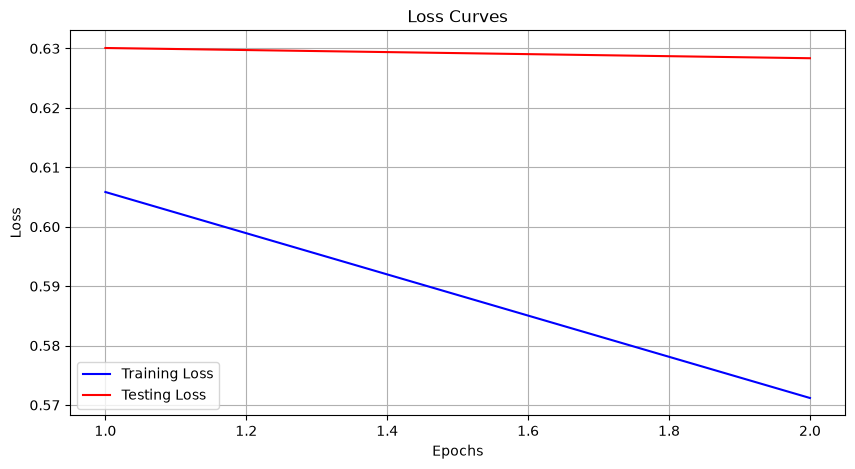

In [29]:
Graph='graph/loss_Curve'
os.makedirs(Graph,exist_ok=True)

# After training and testing
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Testing Loss', color='red')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Save the plot to output
plt.savefig(os.path.join(Graph,'loss_curves.png'))  # Save in Kaggle working directory

plt.show()  # Display the plot


# Model Debuggin

## ACTIVATION STORAGE

In [30]:
layer_outputs = OrderedDict()

## FORWARD HOOK

In [31]:
def save_activation(name):

    def hook(module, input, output):

        if isinstance(output, tuple):
            output = output[0]

        layer_outputs[name] = output.detach()

    return hook


## REGISTER HOOKS

In [32]:
def register_hooks(model):

    for name, module in model.named_modules():

        if isinstance(
            module,
            (
                nn.Conv2d,
                nn.Linear,
                nn.LayerNorm,
            )
        ):

            module.register_forward_hook(
                save_activation(name)
            )

        # Custom classes
        elif module.__class__.__name__ in [
            "WindowAttention",
            "SwinBlock",
            "PatchMerging",
            "PatchEmbed"
        ]:

            module.register_forward_hook(
                save_activation(name)
            )

    print("✅ Hooks Registered")

## ANALYZE ACTIVATIONS

In [33]:
def analyze_activations():

    print("\n================ ACTIVATION ANALYSIS ================\n")

    for name, act in layer_outputs.items():

        try:

            mean = act.mean().item()
            std = act.std().item()
            mx = act.max().item()
            mn = act.min().item()

            print(
                f"{name:40} | "
                f"mean={mean:.5f} | "
                f"std={std:.5f} | "
                f"max={mx:.5f} | "
                f"min={mn:.5f}"
            )

            # Detect bad layers
            if std < 0.01:
                print(f"⚠️ POSSIBLE COLLAPSED FEATURES -> {name}")

            if abs(mean) > 50:
                print(f"⚠️ POSSIBLE EXPLODING ACTIVATION -> {name}")

        except:
            pass

## VISUALIZE FEATURE MAPS

In [34]:
def visualize_feature_maps(layer_name, num_maps=16):

    if layer_name not in layer_outputs:

        print(f"❌ Layer not found: {layer_name}")
        return

    feat = layer_outputs[layer_name]

    # Conv feature maps
    if feat.dim() == 4:

        feat = feat[0]

    # Transformer feature maps
    elif feat.dim() == 3:

        feat = feat[0]

        num_tokens = feat.shape[0]
        dim = feat.shape[1]

        side = int(num_tokens ** 0.5)

        feat = feat.reshape(side, side, dim)
        feat = feat.permute(2, 0, 1)

    else:

        print("❌ Unsupported feature dimension")
        return

    num_maps = min(num_maps, feat.shape[0])

    plt.figure(figsize=(12, 12))

    for i in range(num_maps):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            feat[i].cpu().numpy(),
            cmap='gray'
        )

        plt.axis('off')

    plt.suptitle(layer_name)

    plt.tight_layout()

    plt.show()

## GRADIENT FLOW ANALYSIS

In [35]:
def analyze_gradients(model):

    print("\n================ GRADIENT ANALYSIS ================\n")

    for name, param in model.named_parameters():

        if param.grad is not None:

            grad_mean = param.grad.abs().mean().item()
            grad_max = param.grad.abs().max().item()

            print(
                f"{name:50} | "
                f"grad_mean={grad_mean:.8f} | "
                f"grad_max={grad_max:.8f}"
            )

            # Vanishing gradient
            if grad_mean < 1e-7:

                print(f"⚠️ VANISHING GRADIENT -> {name}")

            # Exploding gradient
            if grad_max > 10:

                print(f"⚠️ EXPLODING GRADIENT -> {name}")

## MAIN DEBUG FUNCTION

In [36]:
def main_debug(val_loader):
    
    print("🚀 Starting Layer Debugging...\n")
    
    # Register hooks
    register_hooks(model)
    model.eval()
    
    # Get one batch
    images, labels = next(iter(val_loader))
    images = images.to(device)
    labels = labels.to(device)
    
    # Forward pass
    outputs = model(images)
    
    # Loss
    loss = criterion(outputs[:, 0:1], outputs[:, 1:], clean[:, 0:1], clean[:, 1:])

    
    # Backward pass
    loss.backward()
    
    # ANALYZE ACTIVATIONS
    analyze_activations()

    # ANALYZE GRADIENTS
    analyze_gradients(model)

    # VISUALIZE IMPORTANT LAYERS
    important_layers = [

        "patch_embed.proj",

        "stage1.0.attn",

        "stage2.0.attn",

        "stage3.0.attn",

        "head"
    ]

    for layer_name in important_layers:

        if layer_name in layer_outputs:

            print(f"\n📊 Visualizing -> {layer_name}")

            visualize_feature_maps(layer_name)
    print("\n✅ Layer Debugging Complete")

## RUN

In [37]:
# main_debug(val_loader=test_loader)

# Load the Model

In [38]:
# model.load_state_dict(torch.load(
#         "/kaggle/input/models/alhossainabid/source-seperation-both-model/pytorch/default/3/best_model.pth",
#         map_location=device))

# model.eval()
# print("Model Load Successfull")

# Evaluation

In [39]:
import requests
import mir_eval
from torchmetrics.audio import SignalDistortionRatio

import numpy as np
import librosa

def mos_to_raw_nb(mos_lqo):
    a = 1.4945
    b = 4.6607
    
    x = (4.999 - 0.999) / (mos_lqo - 0.999) - 1
    raw = (b - np.log(x)) / a
    return raw

APPS_SCRIPT_URL = "https://script.google.com/macros/s/AKfycbwzGLTgq9Qwy8e-4Wrg44hcNzawgaI9gNMx51x5jSKi3rcM1JWm5APCkTQRBe6ntUNg/exec"
TARGET_SHEET = "Sheet13"

pesq_matrix = [[0.0]*10 for _ in range(10)]
stoi_matrix = [[0.0]*10 for _ in range(10)]
sdr_matrix  = [[0.0]*10 for _ in range(10)]
sir_matrix  = [[0.0]*10 for _ in range(10)]
sar_matrix  = [[0.0]*10 for _ in range(10)]
mos_matrix  = [[0.0]*10 for _ in range(10)]

def run_evaluation_test(Male_path, Raw_Female_path):

    Male, _ = librosa.load(Male_path, sr=SAMPLE_RATE)
    Raw_Female, _ = librosa.load(Raw_Female_path, sr=SAMPLE_RATE)

    _, _, Female_frames = mixed_Male_with_Raw_Female(
        Male, Raw_Female, FRAME_LENGTH, SNR
    )

    # ========= INFERENCE =========
    Female_mag_linear, Female_phase = extract_stft_features(
        Female_frames, N_FFT, HOP_LENGTH
    )

    Female_mag = torch.tensor(Female_mag_linear ** 0.3, dtype=torch.float32)
    Female_phase = np.angle(Female_phase)

    Female_phase_sin, Female_phase_cos = normalize_phase_cyclic(Female_phase)

    Female_train = torch.stack((
        Female_mag,
        torch.tensor(Female_phase_sin, dtype=torch.float32),
        torch.tensor(Female_phase_cos, dtype=torch.float32)
    ), dim=1).to(device)



    with torch.no_grad():
        pred = model(Female_train).cpu().numpy()

    # ========= POSTPROCESS =========
    pred_mask = pred[:,0]
    pred_sin = pred[:, 1]
    pred_cos = pred[:, 2]

    estimated_mag = pred_mask * Female_mag_linear

    pred_mag_linear = np.clip(estimated_mag, 0.0, None)

    norm = np.sqrt(pred_sin**2 + pred_cos**2) + 1e-10
    pred_sin /= norm
    pred_cos /= norm

    enhanced_frames = []
    for i in range(len(pred_mag_linear)):
        complex_phase = pred_cos[i] + 1j * pred_sin[i]
        complex_matrix = pred_mag_linear[i] * complex_phase

        frame_audio = librosa.istft(
            complex_matrix,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            length=FRAME_LENGTH
        )
        enhanced_frames.append(frame_audio)

    enhanced = np.concatenate(enhanced_frames)

    ref = Male[:len(enhanced)]
    deg = enhanced

    Female_speech = Female_frames.reshape(-1)[:len(enhanced)]
    estimated_Raw_Female = Female_speech - deg
    Raw_Female = Raw_Female[:len(enhanced)]

    # ========= METRICS =========

    # PESQ & STOI
    pesq_score = pesq(SAMPLE_RATE, ref, deg, 'nb')
    pesq_score1 = mos_to_raw_nb(pesq_score)
    stoi_score = stoi(ref, deg, SAMPLE_RATE, False)

    # SDR / SIR / SAR
    reference_sources = np.stack([ref, Raw_Female], axis=0)
    estimated_sources = np.stack([deg, estimated_Raw_Female], axis=0)

    sdr, sir, sar, _ = mir_eval.separation.bss_eval_sources(
        reference_sources, estimated_sources
    )

    print(f"PESQ: {pesq_score:.3f} | mos: {pesq_score1:.3f} | STOI: {stoi_score:.3f} | "
          f"SDR: {sdr[0]:.3f} | SIR: {sir[0]:.3f} | SAR: {sar[0]:.3f}")

    return (
        round(pesq_score, 3),
        round(stoi_score, 3),
        round(sdr[0], 3),
        round(sir[0], 3),
        round(sar[0], 3),
        round(pesq_score1, 3),

    )

# /kaggle/input/timit-f-Male-clip/timitf01.wav
# /kaggle/input/Raw_Female-speech/Raw_Female/Raw_Female//kaggle/input/Raw_Female-speech/Raw_Female/Raw_Female/n01.wav
speech_files = [f"M{i:02d}.wav" for i in range(1, 11)]
Raw_Female_files  = [f"F{i:02d}.wav" for i in range(1, 11)]

for si, s in enumerate(speech_files):
    for ni, n in enumerate(Raw_Female_files):

        Male_path = f"Dataset/Source Seperation clipping Dataset/Grid Male/{s}"
        Raw_Female_path = f"Dataset/Source Seperation clipping Dataset/Grid Female/{n}"

        pesq_score, stoi_score, sdr_score, sir_score, sar_score, mos = \
            run_evaluation_test(Male_path, Raw_Female_path)

        pesq_matrix[si][ni] = pesq_score
        stoi_matrix[si][ni] = stoi_score
        sdr_matrix[si][ni]  = sdr_score
        sir_matrix[si][ni]  = sir_score
        sar_matrix[si][ni]  = sar_score
        mos_matrix[si][ni]  = mos



        
print("✅ All evaluations completed.")


payload = {
    "sheet": TARGET_SHEET,
    "pesq": pesq_matrix,
    "stoi": stoi_matrix,
    "sdr":  sdr_matrix,
    "sir":  sir_matrix,
    "sar":  sar_matrix,
    "mos":  mos_matrix
}

r = requests.post(APPS_SCRIPT_URL, json=payload, timeout=120)
print("Server response:", r.text)

C:\Users\eaabi\AppData\Local\Temp\ipykernel_5100\2306649349.py:102: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, sir, sar, _ = mir_eval.separation.bss_eval_sources(


PESQ: 1.459 | mos: 1.753 | STOI: 0.656 | SDR: -13.761 | SIR: 0.545 | SAR: -10.850
✅ All evaluations completed.
Server response: {"status":"success","message":"Data written successfully."}
